# Importando as libs e o DataSet

In [259]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [260]:
# Loading datasets TRAIN e TEST
path_projeto = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
path_data_train = os.path.join(path_projeto, "data", "train.csv")
path_data_test = os.path.join(path_projeto, "data", "test.csv")

base_train = pd.read_csv(path_data_train)
base_test = pd.read_csv(path_data_test)

In [261]:
# Concatenando os datasets
base = pd.concat([base_train, base_test], axis=0)

In [262]:
# Salvando o dataset de test
comeco_test = len(base_train)

# Entendendo

Vamos uitlizar o info para ter uma visão geral dos dados. Esse metodo nos mostra o shape do nosso dataset, o nome de cada coluna, o tipo de cada coluna e também a quantiddade de valores não nulos em cada coluna.

In [263]:
base.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 132.9+ KB


Agoras vamos utilizar o método describe para analisar alguns indices estatisticos das colunas.

In [264]:
base.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


Vamos alterar o nome de cada coluna para que todas as letras possam ficar em caixa baixa.

In [265]:
base.columns = base.columns.map(lambda x: x.casefold()) 

Vamos excluir a coluna "PassengerId", pois serve apenas como indice.

In [266]:
base.drop(axis = 1, labels = 'passengerid', inplace=True)

In [267]:
base.head()

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Limpeza e Tratamento

Vamos criar um novo dataframe para receber os dados limpos e tratados, porém vamos manter intacta a estrutura do objeto "base" a partir daqui...

In [277]:
df = base.copy().reset_index().drop(axis=1,labels='index')

## pclass

In [278]:
df['pclass'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1309 entries, 0 to 1308
Series name: pclass
Non-Null Count  Dtype
--------------  -----
1309 non-null   int64
dtypes: int64(1)
memory usage: 10.4 KB


In [279]:
df['pclass'].unique()

array([3, 1, 2])

## name

In [280]:
df['name'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1309 entries, 0 to 1308
Series name: name
Non-Null Count  Dtype 
--------------  ----- 
1309 non-null   object
dtypes: object(1)
memory usage: 10.4+ KB


Vamos remover a variável pois não conseguimos lidar muito bem com os titulos pessoais para a criação de mais uma variável, e de resto essa nos parece ruim para o modelo de decision tree.

In [281]:
# removendo a variável do dataset principal
df.drop(axis=1, labels='name', inplace=True)

## sex

In [282]:
df['sex'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1309 entries, 0 to 1308
Series name: sex
Non-Null Count  Dtype 
--------------  ----- 
1309 non-null   object
dtypes: object(1)
memory usage: 10.4+ KB


Vamos trocar 'female' e 'male' para 0 e 1 respectivamente.

In [283]:
df['sex'].replace(['male','female'], [0,1], inplace=True)

In [284]:
df.head(3)

,survived,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0.0,3,0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1.0,1,1,38.0,1,0,PC 17599,71.2833,C85,C
2,1.0,3,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## age

In [285]:
df['age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1309 entries, 0 to 1308
Series name: age
Non-Null Count  Dtype  
--------------  -----  
1046 non-null   float64
dtypes: float64(1)
memory usage: 10.4 KB


Resolvemos preencher os valores vazios de acordo com a média de idade de extratos que criamos de acordo com as variáveis "pcalss" e "sex".

In [287]:
# Preenchendo os valores vazios.
foo = df['age'].iloc[:891].fillna(
    df.iloc[:891, :].groupby(by=['pclass','sex'])['age'].transform(func='mean'))

bar = df['age'].iloc[891:].fillna(
    df.iloc[891:,:].groupby(by=['pclass','sex'])['age'].transform(func='mean'))

df['age'] = pd.concat([foo,bar])

In [288]:
df.iloc[:891, :].groupby(by=['pclass','sex'])['age'].mean()

pclass  sex
1       0      41.281386
        1      34.611765
2       0      30.740707
        1      28.722973
3       0      26.507589
        1      21.750000
Name: age, dtype: float64

## sibsp

In [281]:
df['sibsp'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1309 entries, 0 to 1308
Series name: sibsp
Non-Null Count  Dtype
--------------  -----
1309 non-null   int64
dtypes: int64(1)
memory usage: 10.4 KB


In [99]:
df['sibsp'].unique()

array([1, 0, 3, 4, 2, 5, 8])

## parch

In [100]:
df['parch'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: parch
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


In [101]:
df['parch'].unique()

array([0, 1, 2, 5, 3, 4, 6])

## ticket

Vamos remover a variável.

In [282]:
df['ticket'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1309 entries, 0 to 1308
Series name: ticket
Non-Null Count  Dtype 
--------------  ----- 
1309 non-null   object
dtypes: object(1)
memory usage: 10.4+ KB


In [284]:
df.drop(axis=1, labels='ticket',inplace=True)

## fare

In [289]:
df['fare'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1309 entries, 0 to 1308
Series name: fare
Non-Null Count  Dtype  
--------------  -----  
1308 non-null   float64
dtypes: float64(1)
memory usage: 10.4 KB


In [310]:
df['fare'].fillna(base.groupby(['embarked', 'pclass'])['fare'].median()['S'][3], inplace=True)

## cabin

Vamos remover a variável.

In [106]:
df['cabin'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: cabin
Non-Null Count  Dtype 
--------------  ----- 
204 non-null    object
dtypes: object(1)
memory usage: 7.1+ KB


In [286]:
df.drop(axis=1, labels='cabin',inplace=True)

## embarked

Seguimos o site (https://www.encyclopedia-titanica.org/titanic-survivor/martha-evelyn-stone.html) para preencher os valores vazios dessa coluna.

In [314]:
df['embarked'].fillna("S", inplace=True)

In [315]:
df['embarked'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1309 entries, 0 to 1308
Series name: embarked
Non-Null Count  Dtype 
--------------  ----- 
1309 non-null   object
dtypes: object(1)
memory usage: 10.4+ KB


In [378]:
df['embarked'].replace(['S', 'C', 'Q'], [1, 2, 3], inplace=True)

## Descompactando os dados de treino e teste

In [379]:
df_train = df.iloc[:891, :].copy()
df_test = df.iloc[891:, :].copy()

# Análise exploratória

## pclass

### univariada

In [320]:
# informações gerais
df_train[['pclass']].describe()

,pclass
count,891.000000
mean,2.308642
std,0.836071
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,3.000000


In [321]:
# frequencia absoluta
pd.DataFrame(df_train['pclass'].value_counts(sort = False).sort_index())

,pclass
1,216
2,184
3,491


In [325]:
# frequencia relativa
pd.DataFrame((df_train['pclass'].value_counts(normalize = True).sort_index() * 100).round(2))

,pclass
1,24.24
2,20.65
3,55.11


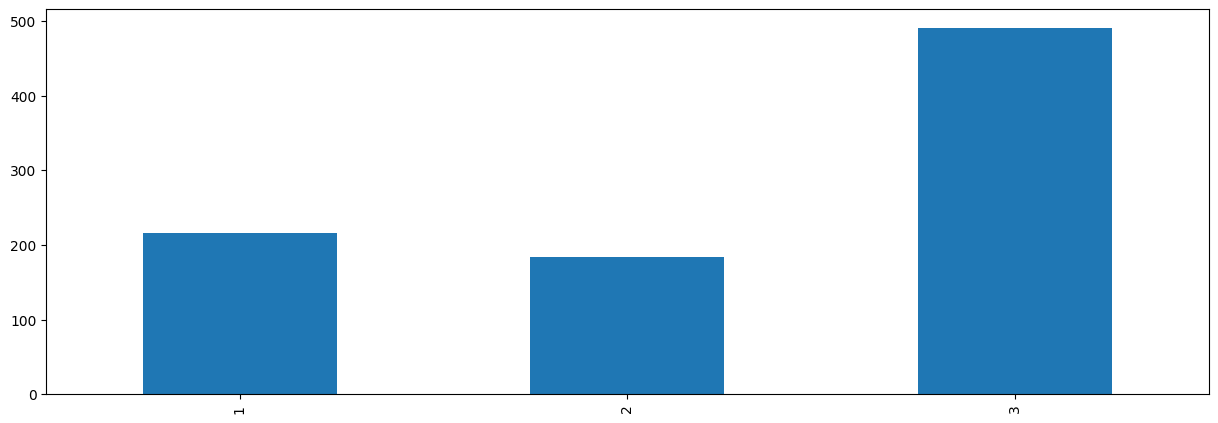

In [326]:
# gráfico de frequência
foo = df_train['pclass'].value_counts().sort_index()
foo.plot(kind='bar', figsize = (15, 5))
plt.show()

### bivariada

#### with survived

In [328]:
(df_train.groupby(by = 'pclass')['survived'].value_counts(normalize = True).sort_index() * 100).round(2)

pclass  survived
1       0.0         37.04
        1.0         62.96
2       0.0         52.72
        1.0         47.28
3       0.0         75.76
        1.0         24.24
Name: survived, dtype: float64

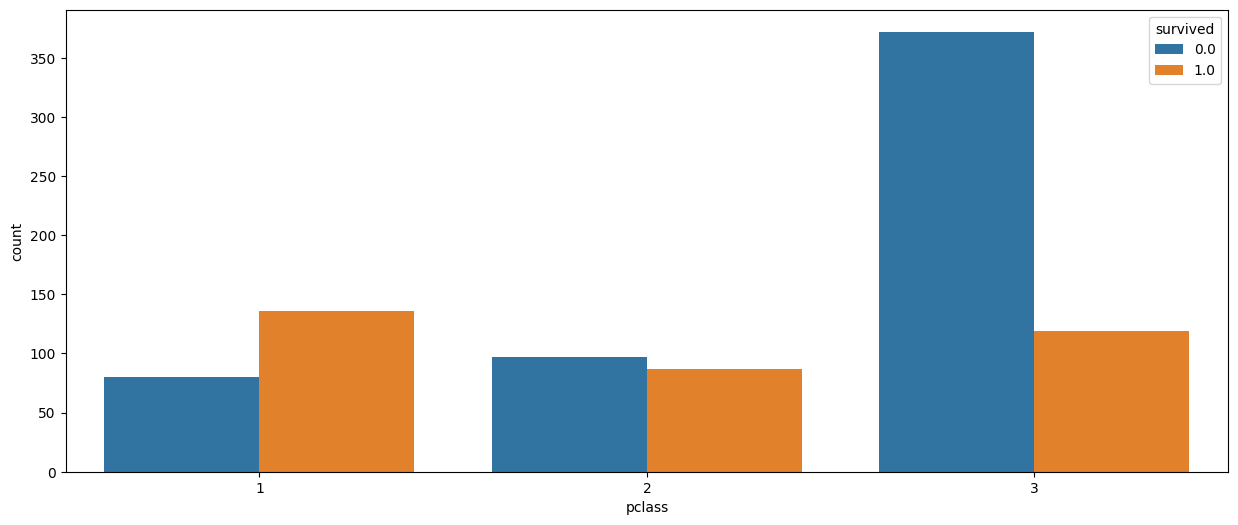

In [330]:
# correlação de classe sobrevivencia ou náo
plt.figure(figsize=(15, 6))
sns.countplot(data = df_train, x='pclass', hue='survived')
plt.show()

#### with sex

In [331]:
(df_train.groupby(by = 'pclass')['sex'].value_counts(normalize = True).sort_index() * 100).round(2)

pclass  sex
1       0      56.48
        1      43.52
2       0      58.70
        1      41.30
3       0      70.67
        1      29.33
Name: sex, dtype: float64

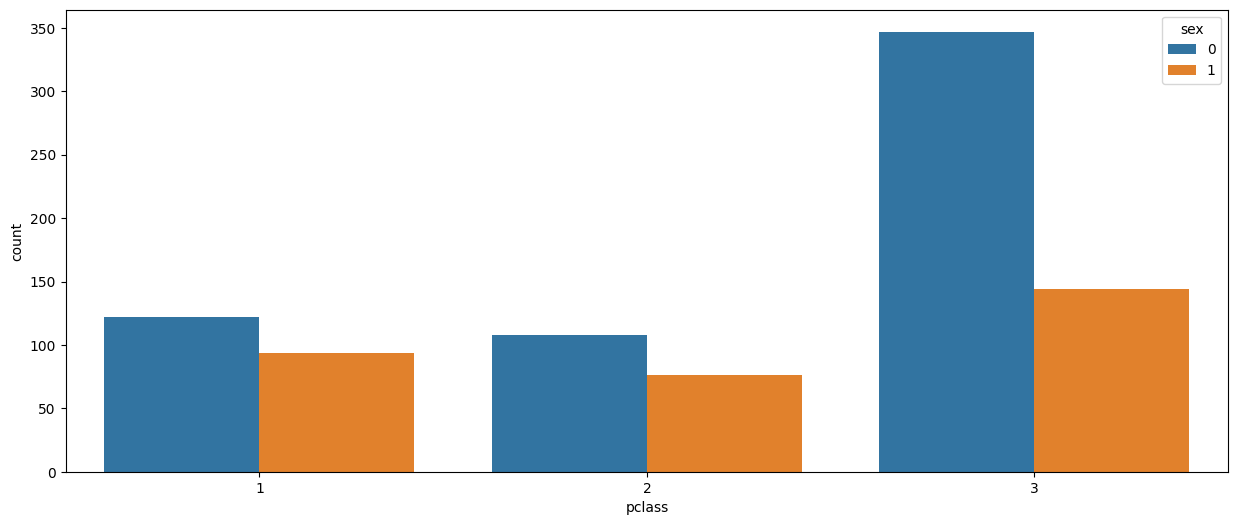

In [332]:
# correlação de classe sobrevivencia ou náo
plt.figure(figsize=(15, 6))
sns.countplot(data = df_train, x='pclass', hue='sex')
plt.show()

### multivariada

#### with sex and survived

In [334]:
# quantos % das mulheres soreviveu
(df_train.groupby(by = ['pclass', 'sex'])['survived'].value_counts(normalize=True).sort_index() * 100).round(2)

pclass  sex  survived
1       0    0.0         63.11
             1.0         36.89
        1    0.0          3.19
             1.0         96.81
2       0    0.0         84.26
             1.0         15.74
        1    0.0          7.89
             1.0         92.11
3       0    0.0         86.46
             1.0         13.54
        1    0.0         50.00
             1.0         50.00
Name: survived, dtype: float64

## sex

### univariada

In [338]:
# frequencia absoluta
pd.DataFrame(df_train['sex'].value_counts().sort_index())

,sex
0,577
1,314


In [340]:
# frequencia relativa
pd.DataFrame((df_train['sex'].value_counts(normalize = True).sort_index() * 100).round(2))

,sex
0,64.76
1,35.24


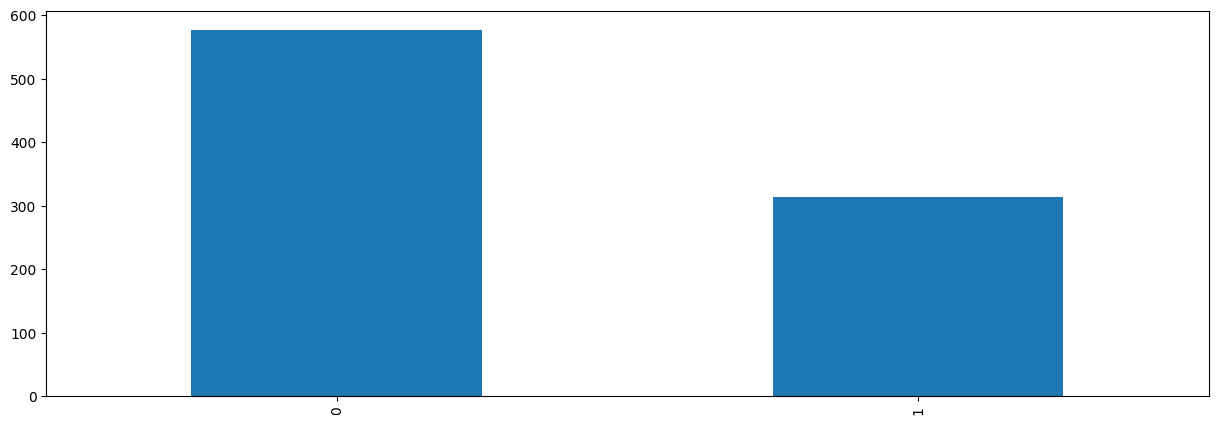

In [342]:
# gráfico de frequência
foo = df_train['sex'].value_counts(sort=False)
foo.plot(kind='bar', figsize = (15, 5))
plt.show()

### bivariada

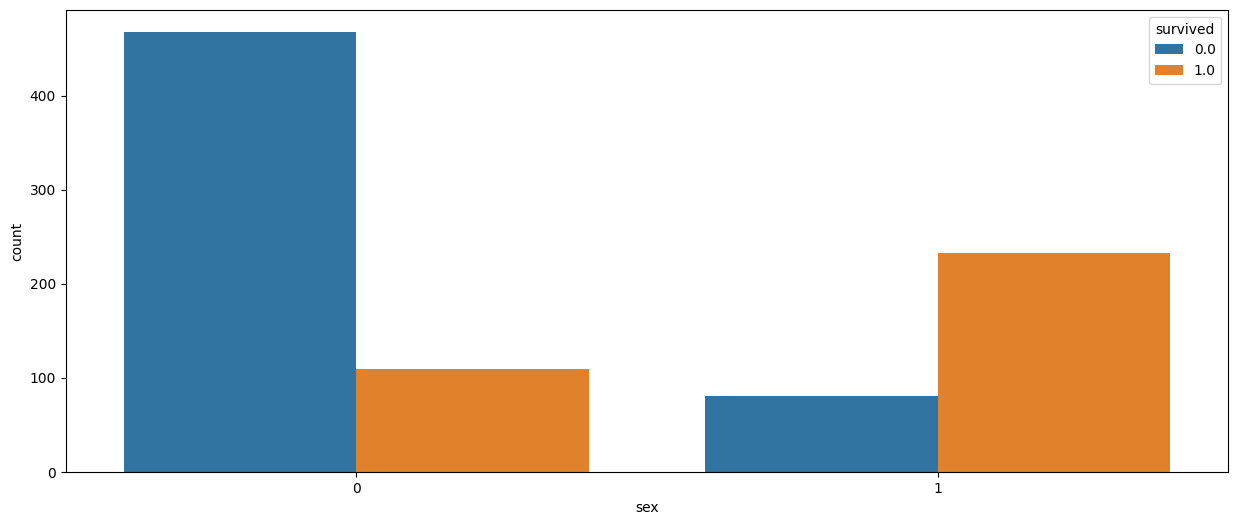

In [343]:
plt.figure(figsize=(15, 6))

sns.countplot(data=df_train, x='sex', hue='survived')
plt.show()

### multivariada

## age

In [347]:
# frequencia absoluta
pd.DataFrame(df_train['age'].value_counts())

,age
26.507589,94
21.750000,42
24.000000,30
22.000000,27
18.000000,26
...,...
14.500000,1
70.500000,1
12.000000,1
36.500000,1


### univariada

In [127]:
df2[['age']].describe()

,age
count,891.000000
mean,29.718485
std,13.260004
min,0.420000
25%,22.000000
50%,30.000000
75%,36.000000
max,80.000000


In [128]:
# moda
df2['age'].mode()[0]

32.0

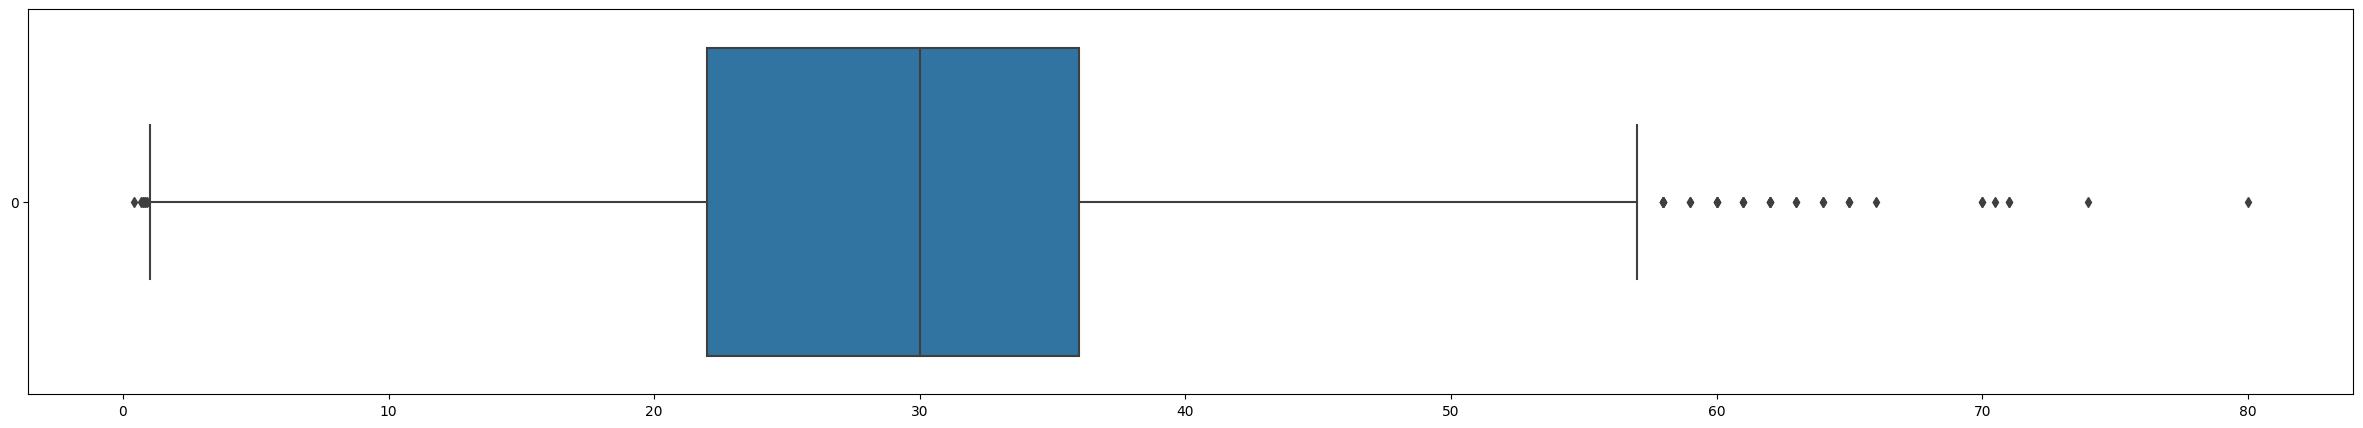

In [129]:
plt.figure(figsize=(30, 5))
sns.boxplot(df2['age'], orient='h')
plt.show()

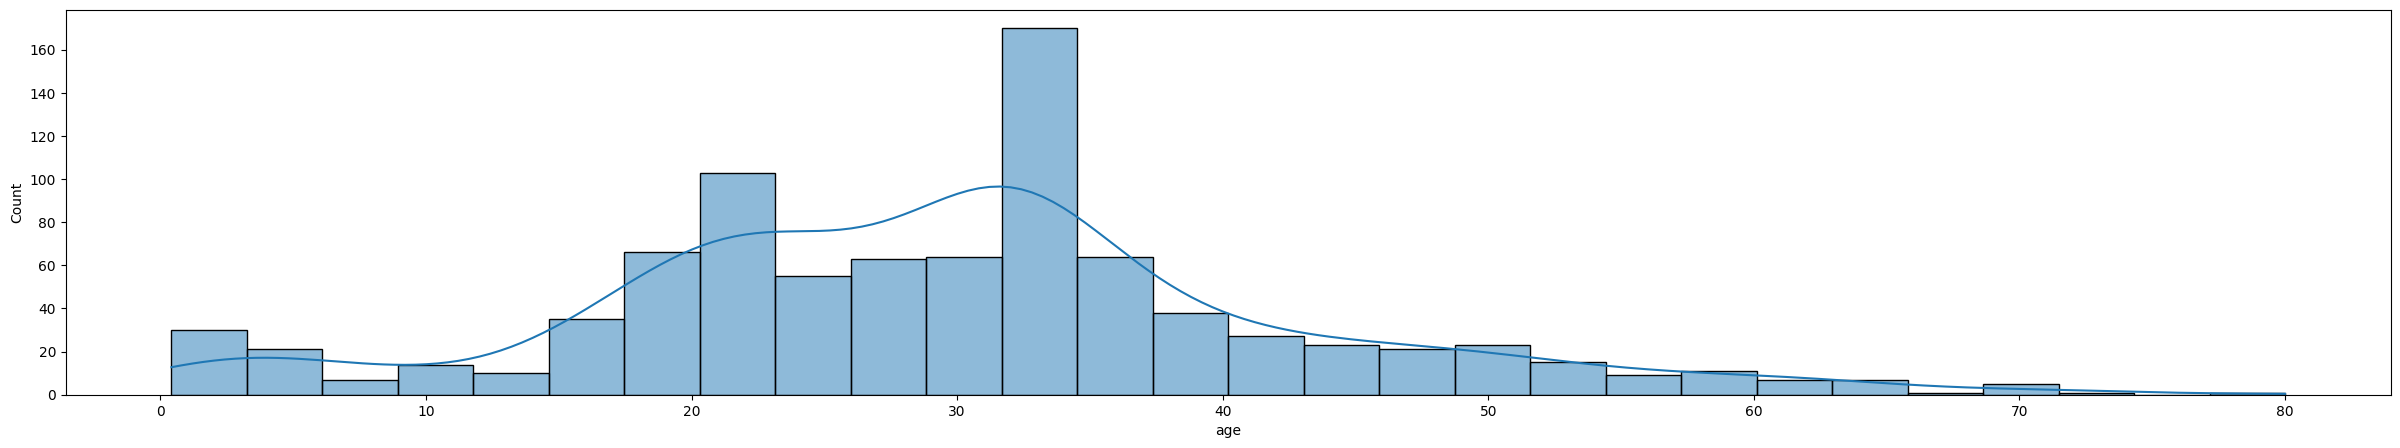

In [130]:
plt.figure(figsize=(30, 5))
sns.histplot(df2['age'], kde=True)
plt.show()

### bivariada

In [131]:
foo = pd.cut(x=df2['age'],bins=[i for i in range(0, 81, 5)]).rename('age_class')
df3 = pd.concat([df2,foo], axis = 1)
df3

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,title,age_class
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,"(20, 25]"
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,"(35, 40]"
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,"(25, 30]"
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,Mrs,"(30, 35]"
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,Mr,"(30, 35]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S,Rev,"(25, 30]"
887,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,S,Miss,"(15, 20]"
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,22.0,1,2,W./C. 6607,23.4500,NaN,S,Miss,"(20, 25]"
889,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C,Mr,"(25, 30]"


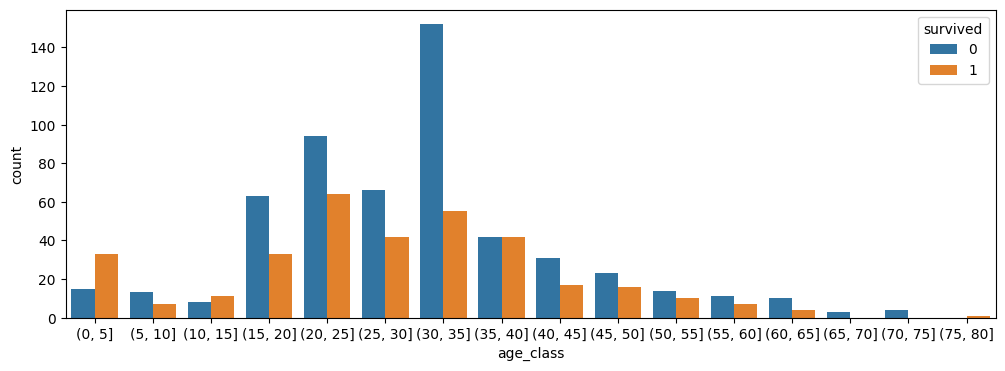

In [132]:
plt.figure(figsize=(12, 4))

sns.countplot(data=df3, x = 'age_class', hue='survived')
plt.show()

In [133]:
# coeficiente de spearman
df3['age'].corr(method = 'spearman', other=df3['survived'])

-0.06756616445494003

### multivariada

##  fare

### univariada

(-0.513, 51.233]      82.154882
(51.233, 102.466]     11.896745
(102.466, 153.699]     3.479237
(153.699, 204.932]     0.224467
(204.932, 256.165]     1.234568
(256.165, 307.398]     0.673401
(307.398, 358.63]      0.000000
(358.63, 409.863]      0.000000
(409.863, 461.096]     0.000000
(461.096, 512.329]     0.336700
Name: fare, dtype: float64


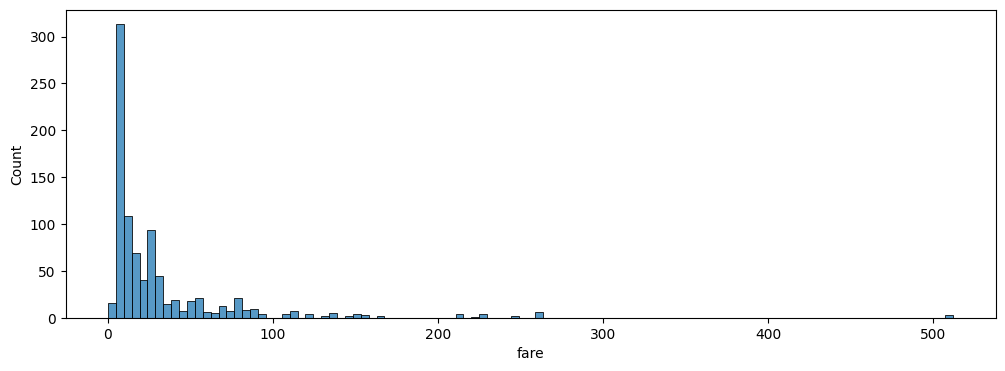

In [348]:
# Distribuição
fare = df_train['fare']
print((fare.value_counts(bins = 10, normalize=True)*100).sort_index())
plt.figure(figsize=(12, 4))
sns.histplot(data=fare)
plt.show()

In [349]:
# Tendência central
print(fare.describe())

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


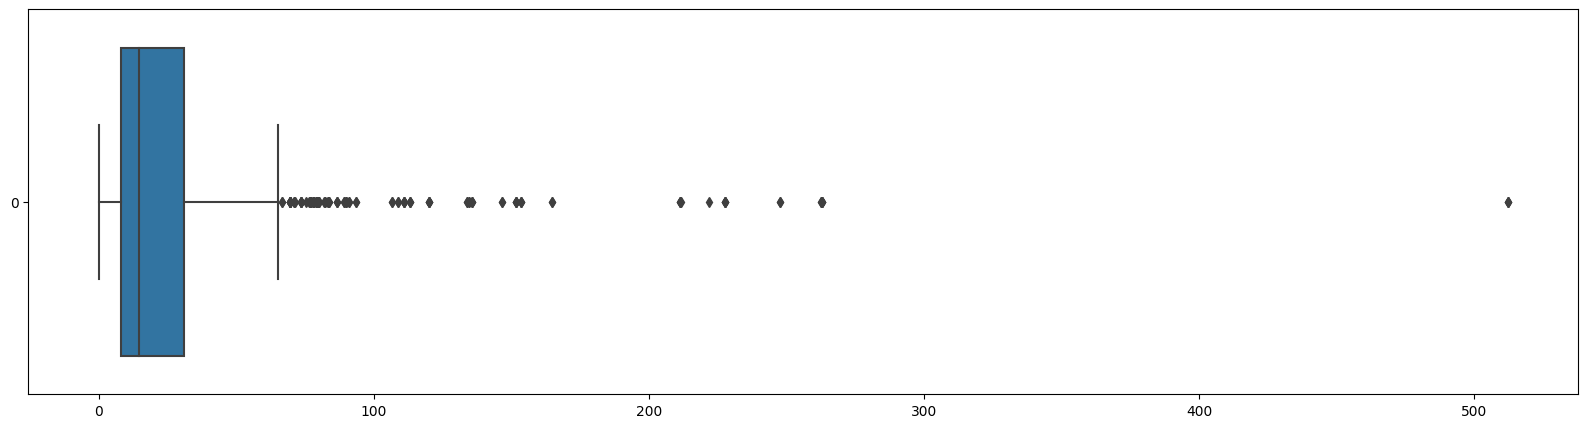

In [351]:
# Dispersão
plt.figure(figsize=(20,5))
sns.boxplot(data=fare, orient='h')
plt.show()

### bivariada

,count,mean,std,min,25%,50%,75%,max
survived,,,,,,,,
0.0,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0000
1.0,342.0,48.395408,66.596998,0.0,12.4750,26.0,57.0,512.3292


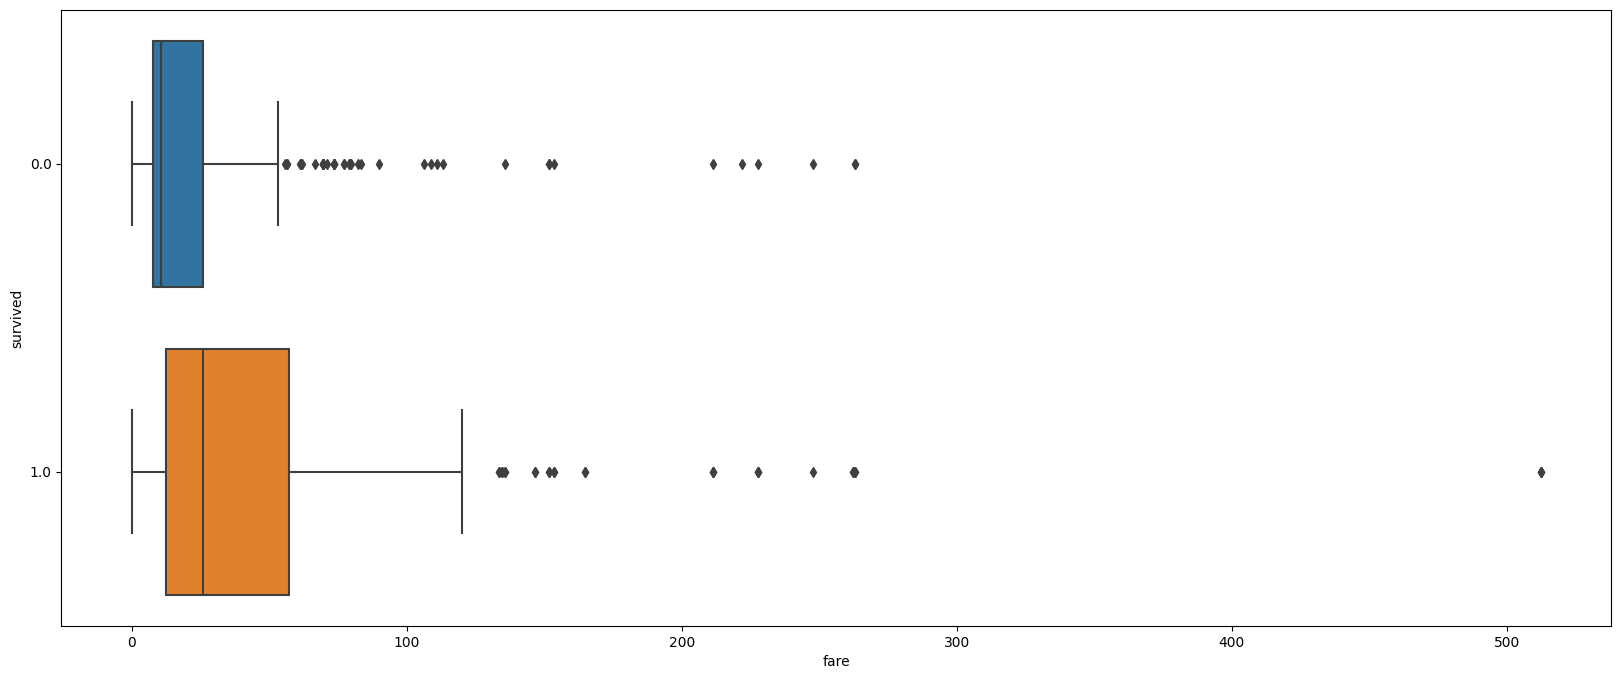

In [355]:
# corr. survived
display(df_train.groupby('survived')['fare'].describe())
print()
plt.figure(figsize=(20,8))
sns.boxplot(x=fare,y=df_train['survived'], orient='h')
plt.show()

        count       mean        std  min       25%      50%   75%       max
pclass                                                                     
1       216.0  84.154687  78.380373  0.0  30.92395  60.2875  93.5  512.3292
2       184.0  20.662183  13.417399  0.0  13.00000  14.2500  26.0   73.5000
3       491.0  13.675550  11.778142  0.0   7.75000   8.0500  15.5   69.5500


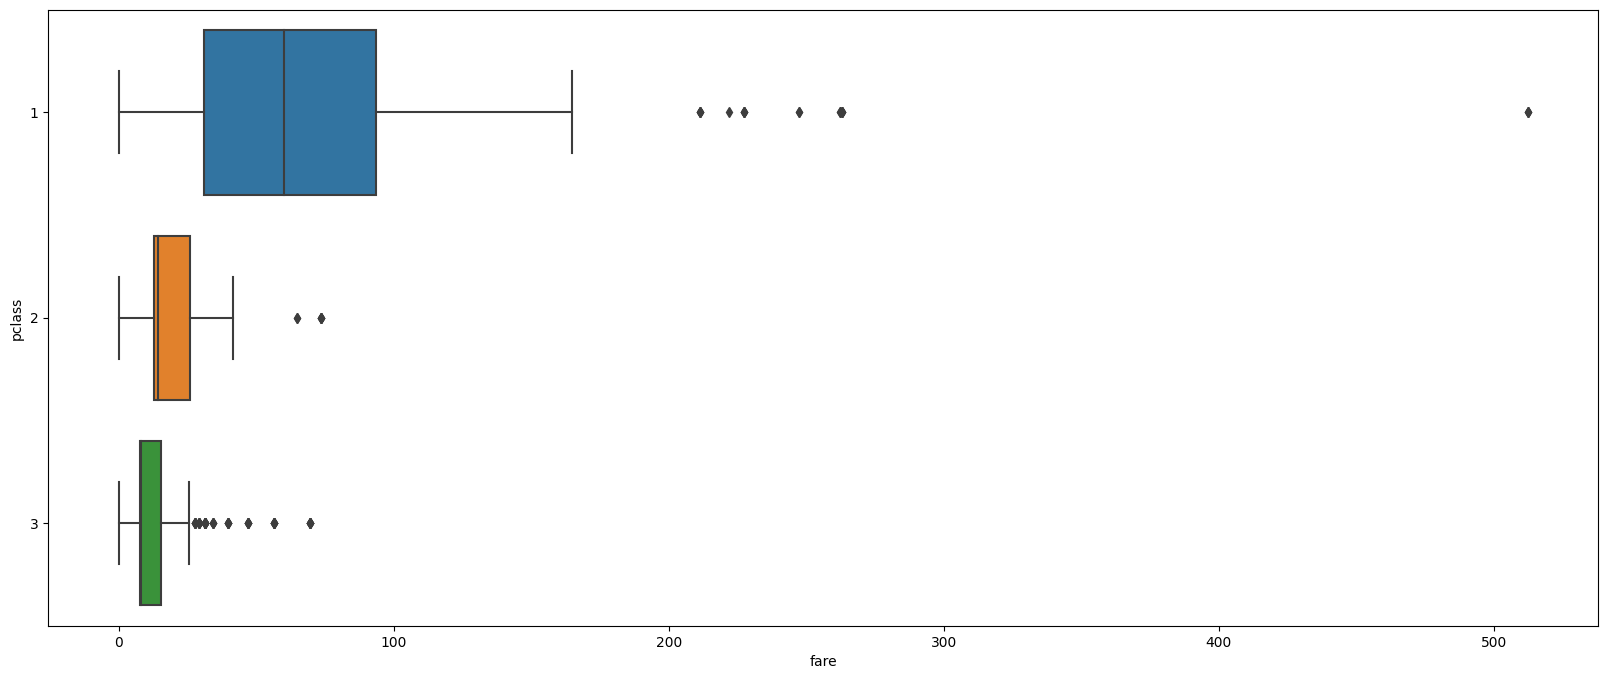

In [138]:
# corr. classe
print(df.groupby('pclass')['fare'].describe())
plt.figure(figsize=(20,8))
sns.boxplot(x=fare,y=df['pclass'], orient='h')
plt.show()

count    491.000000
mean      13.675550
std       11.778142
min        0.000000
25%        7.750000
50%        8.050000
75%       15.500000
max       69.550000
Name: fare, dtype: float64
moda = 8.05


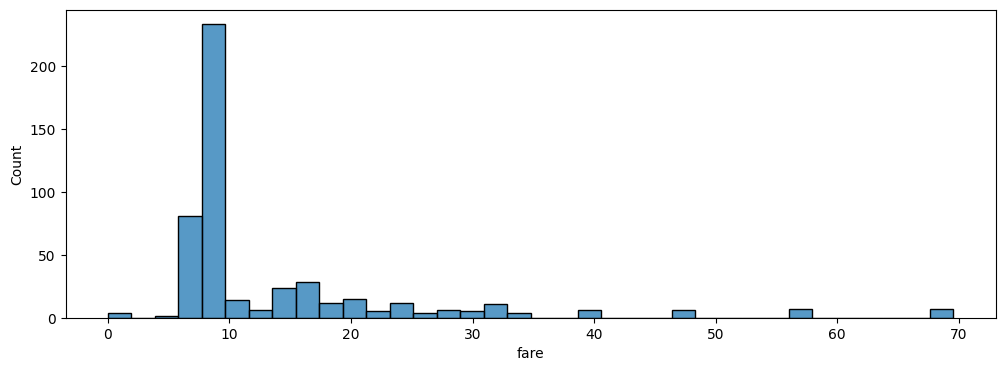

count    184.000000
mean      20.662183
std       13.417399
min        0.000000
25%       13.000000
50%       14.250000
75%       26.000000
max       73.500000
Name: fare, dtype: float64
moda = 13.0


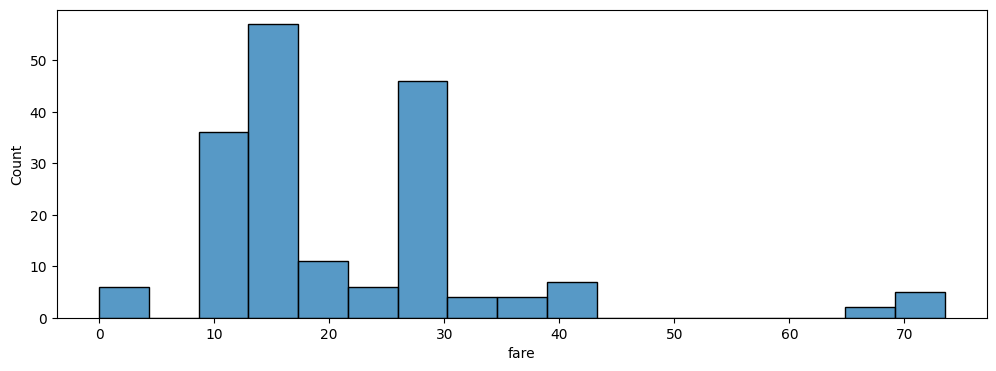

count    216.000000
mean      84.154687
std       78.380373
min        0.000000
25%       30.923950
50%       60.287500
75%       93.500000
max      512.329200
Name: fare, dtype: float64
moda = 26.55


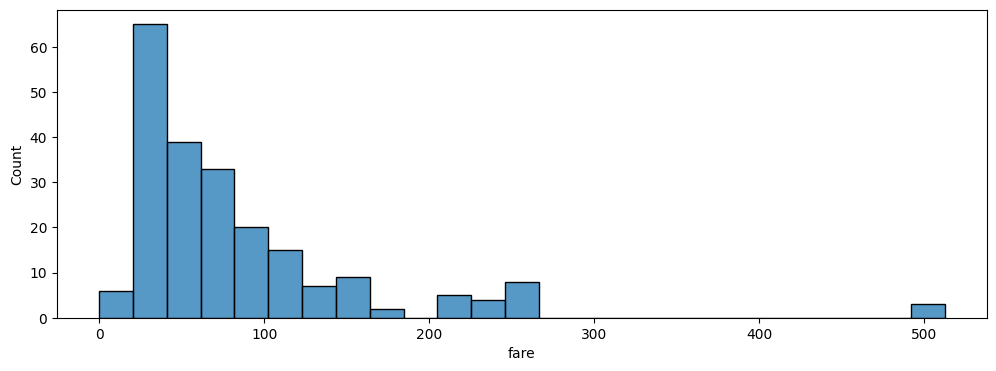

In [356]:
for i in [3,2,1]:
    foo = df_train.query(f'pclass == {i}')['fare']
    print(foo.describe())
    print(f'moda = {foo.mode()[0]}')
    plt.figure(figsize=(12, 4))
    sns.histplot(data=foo)
    plt.show()

### multivariada

In [140]:
#

## embarked

In [357]:
# frequencia absoluta
pd.DataFrame(df_train['embarked'].value_counts(sort = False).sort_index())

,embarked
C,168
Q,77
S,646


In [358]:
# frequencia relativa
pd.DataFrame((df_train['embarked'].value_counts(normalize = True).sort_index() * 100).round(2))

,embarked
C,18.86
Q,8.64
S,72.50


<AxesSubplot: >

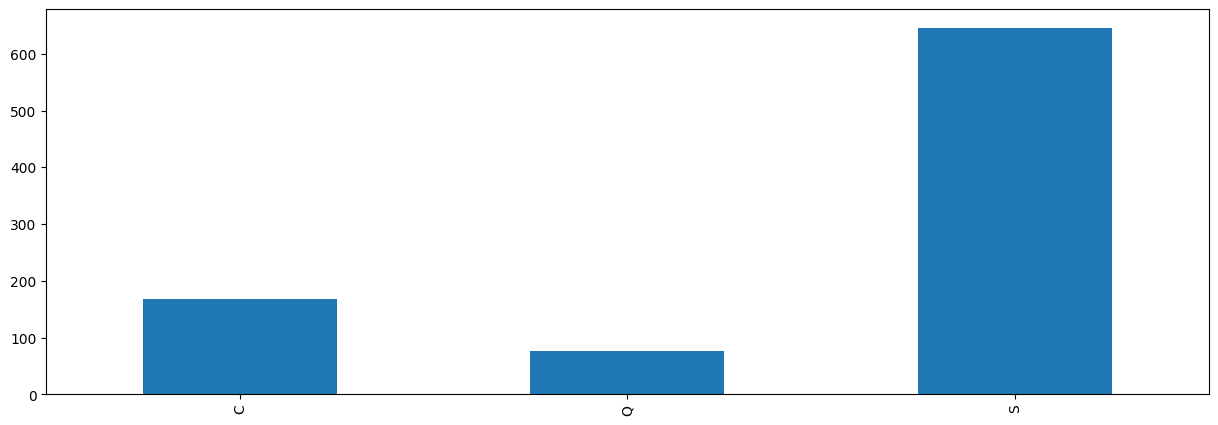

In [359]:
# gráfico de frequência
foo = df_train['embarked'].value_counts().sort_index()
foo.plot(kind='bar', figsize = (15, 5))

In [360]:
(df_train.groupby(by = 'embarked')['survived'].value_counts(normalize = True).sort_index() * 100).round(2)

embarked  survived
C         0.0         44.64
          1.0         55.36
Q         0.0         61.04
          1.0         38.96
S         0.0         66.10
          1.0         33.90
Name: survived, dtype: float64

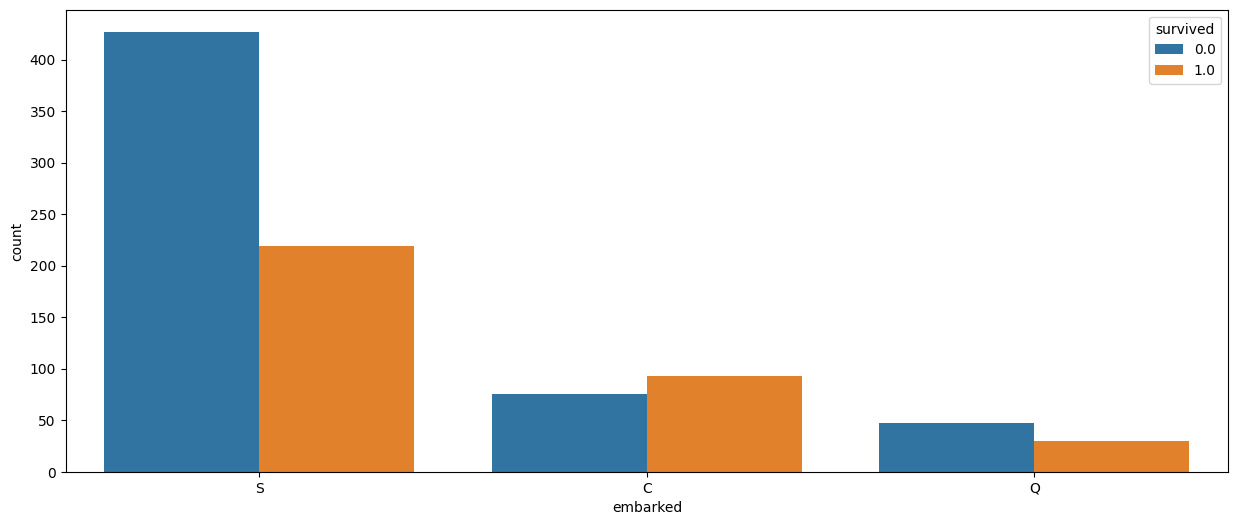

In [361]:
# correlação de classe sobrevivencia ou náo
plt.figure(figsize=(15, 6))
sns.countplot(data = df_train, x='embarked', hue='survived')
plt.show()

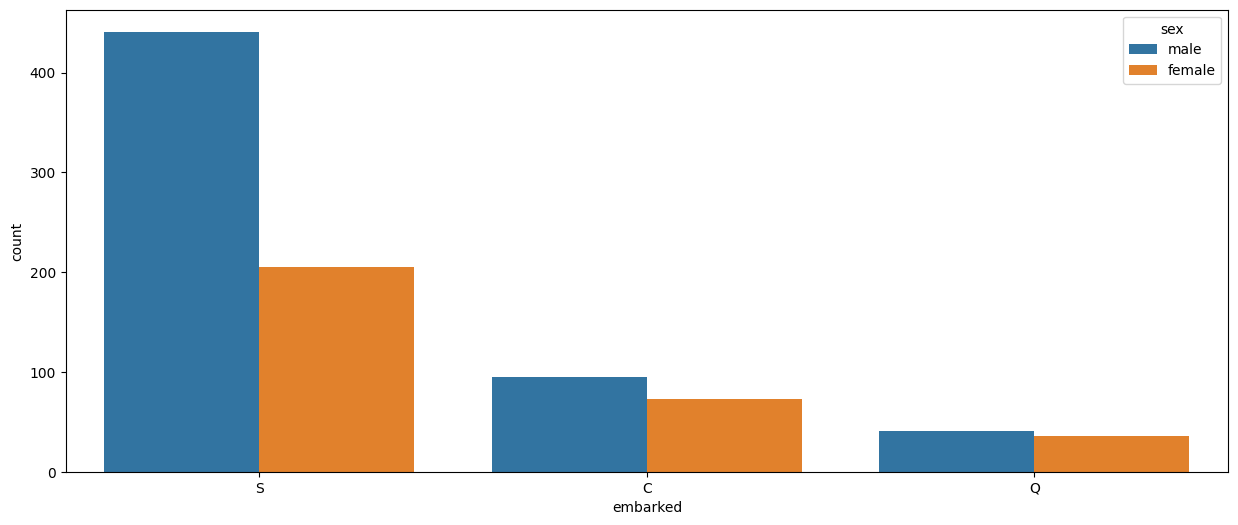

In [146]:
# correlação de classe sobrevivencia ou não
plt.figure(figsize=(15, 6))
sns.countplot(data = df, x='embarked', hue='sex')
plt.show()

#  modelo

In [380]:
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [381]:
# Separando em X e Y

cols = ['pclass', 'sex', 'age', 'fare', 'embarked']
dados = df_train[cols].copy(), df_test[cols].copy(), df_train.survived

X_train, X_test, y_train = dados

In [383]:
# Criando o modelo e treinando o modelo
clf = tree.DecisionTreeClassifier().fit(X_train, y_train)

In [384]:
# Prevendo os dados
y_pred = clf.predict(X_test)